### **Stage2: Exploratory Spatial Data Analysis (ESDA) Analysis**

In [1]:
# Imports and configuration

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from libpysal.weights import KNN
from esda.moran import Moran, Moran_Local
from esda import G_Local
from scipy import stats

# Reproducibility — ensures permutation tests give identical results each run
np.random.seed(42)

# Standard LISA colours
C_HH = '#FF0000'      # High-High (red)
C_LL = '#0000FF'       # Low-Low (blue)
C_HL = '#FF9999'       # High-Low (light pink)
C_LH = '#9999FF'       # Low-High (light blue)
C_NS = '#D3D3D3'       # Not significant (light grey)

# Reusable legends
LISA_LEGEND = [
    Patch(facecolor=C_HH, label='High-High'),
    Patch(facecolor=C_LL, label='Low-Low'),
    Patch(facecolor=C_HL, label='High-Low'),
    Patch(facecolor=C_LH, label='Low-High'),
    Patch(facecolor=C_NS, label='Not Significant')
]

HOTSPOT_LEGEND = [
    Patch(facecolor='#B2182B', label='Hot Spot (99% Confidence)'),
    Patch(facecolor='#EF8A62', label='Hot Spot (95% Confidence)'),
    Patch(facecolor='#FDDBC7', label='Hot Spot (90% Confidence)'),
    Patch(facecolor='#D3D3D3', label='Not Significant'),
    Patch(facecolor='#D1E5F0', label='Cold Spot (90% Confidence)'),
    Patch(facecolor='#67A9CF', label='Cold Spot (95% Confidence)'),
    Patch(facecolor='#2166AC', label='Cold Spot (99% Confidence)')
]

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white'
})

In [4]:
# Load shapefile, create clean columns, validate for NaN
gdf = gpd.read_file('GLA_Master.shp')

# Create clean columns
gdf['IncRate_2020'] = gdf['IncRate'].str.replace('%', '').astype(float)
gdf['IncRate_2016'] = gdf['IncRate_1'] * 100
gdf['VDL_2016'] = gdf['VDL_Ratio1']
gdf['VDL_2020'] = gdf['VDL_Ratio2']
gdf['GreenRatio'] = gdf['PAN_GreenR']
gdf['NoGreen'] = 1 - gdf['GreenRatio']

# NaN validation
analysis_cols = ['IncRate_2016', 'IncRate_2020', 'NO2_2016', 'NO2_2020',
                 'VDL_2016', 'VDL_2020', 'NoGreen']

print('NaN check:')
for col in analysis_cols:
    n_miss = gdf[col].isna().sum()
    if n_miss > 0:
        median_val = gdf[col].median()
        print(f'  WARNING: {col} has {n_miss} NaN(s) - filling with median ({median_val:.4f})')
        gdf[col] = gdf[col].fillna(median_val)
    else:
        print(f'  OK: {col}')

print(f'\nLoaded: {len(gdf)} data zones')
print(f'CRS: {gdf.crs}')

NaN check:
  OK: IncRate_2016
  OK: IncRate_2020
  OK: NO2_2016
  OK: NO2_2020
  OK: VDL_2016
  OK: VDL_2020
  OK: NoGreen

Loaded: 746 data zones
CRS: EPSG:27700


In [5]:
# Constructing a spatial weight matrix

from libpysal.weights import KNN

# Construct spatial weight matrix (KNN k=8, row-standardised)
w = KNN.from_dataframe(gdf, k=8)
w.transform = 'r'

print(f'Spatial weights: K-Nearest Neighbours (k=8)')
print(f'Connected components: {w.n_components}')
print(f'Number of observations: {w.n}')

if w.n_components > 1:
    print('WARNING: Graph has disconnected components.')

Spatial weights: K-Nearest Neighbours (k=8)
Connected components: 1
Number of observations: 746


The KNN spatial weights matrix produced one connected component with no isolated spatial units.

In [6]:
# Global Moran's I for all indicators
# OPTIMISATION: 9999 permutations for more stable p-values
variables = {
    'Income Rate 2016':    gdf['IncRate_2016'],
    'Income Rate 2020':    gdf['IncRate_2020'],
    'NO2 2016':            gdf['NO2_2016'],
    'NO2 2020':            gdf['NO2_2020'],
    'VDL 2016':            gdf['VDL_2016'],
    'VDL 2020':            gdf['VDL_2020'],
    'Lack of Green Space': gdf['NoGreen']
}

print('=' * 72)
print(f'{"Variable":<25} {"Morans I":>10} {"E[I]":>10} {"Z-score":>10} {"p-value":>10}')
print('=' * 72)

moran_results = {}
for name, var in variables.items():
    mi = Moran(var.values, w, permutations=9999)
    moran_results[name] = mi
    sig = '***' if mi.p_sim < 0.01 else ('**' if mi.p_sim < 0.05 else ('*' if mi.p_sim < 0.1 else ''))
    print(f'{name:<25} {mi.I:>10.4f} {mi.EI:>10.4f} {mi.z_sim:>10.3f} {mi.p_sim:>10.4f} {sig}')

print('\nSignificance: *** p<0.01, ** p<0.05, * p<0.1')

Variable                    Morans I       E[I]    Z-score    p-value
Income Rate 2016              0.4223    -0.0013     24.483     0.0001 ***
Income Rate 2020              0.4409    -0.0013     25.290     0.0001 ***
NO2 2016                      0.8458    -0.0013     48.831     0.0001 ***
NO2 2020                      0.8484    -0.0013     49.523     0.0001 ***
VDL 2016                      0.4480    -0.0013     25.654     0.0001 ***
VDL 2020                      0.4724    -0.0013     27.332     0.0001 ***
Lack of Green Space           0.4602    -0.0013     26.506     0.0001 ***

Significance: *** p<0.01, ** p<0.05, * p<0.1


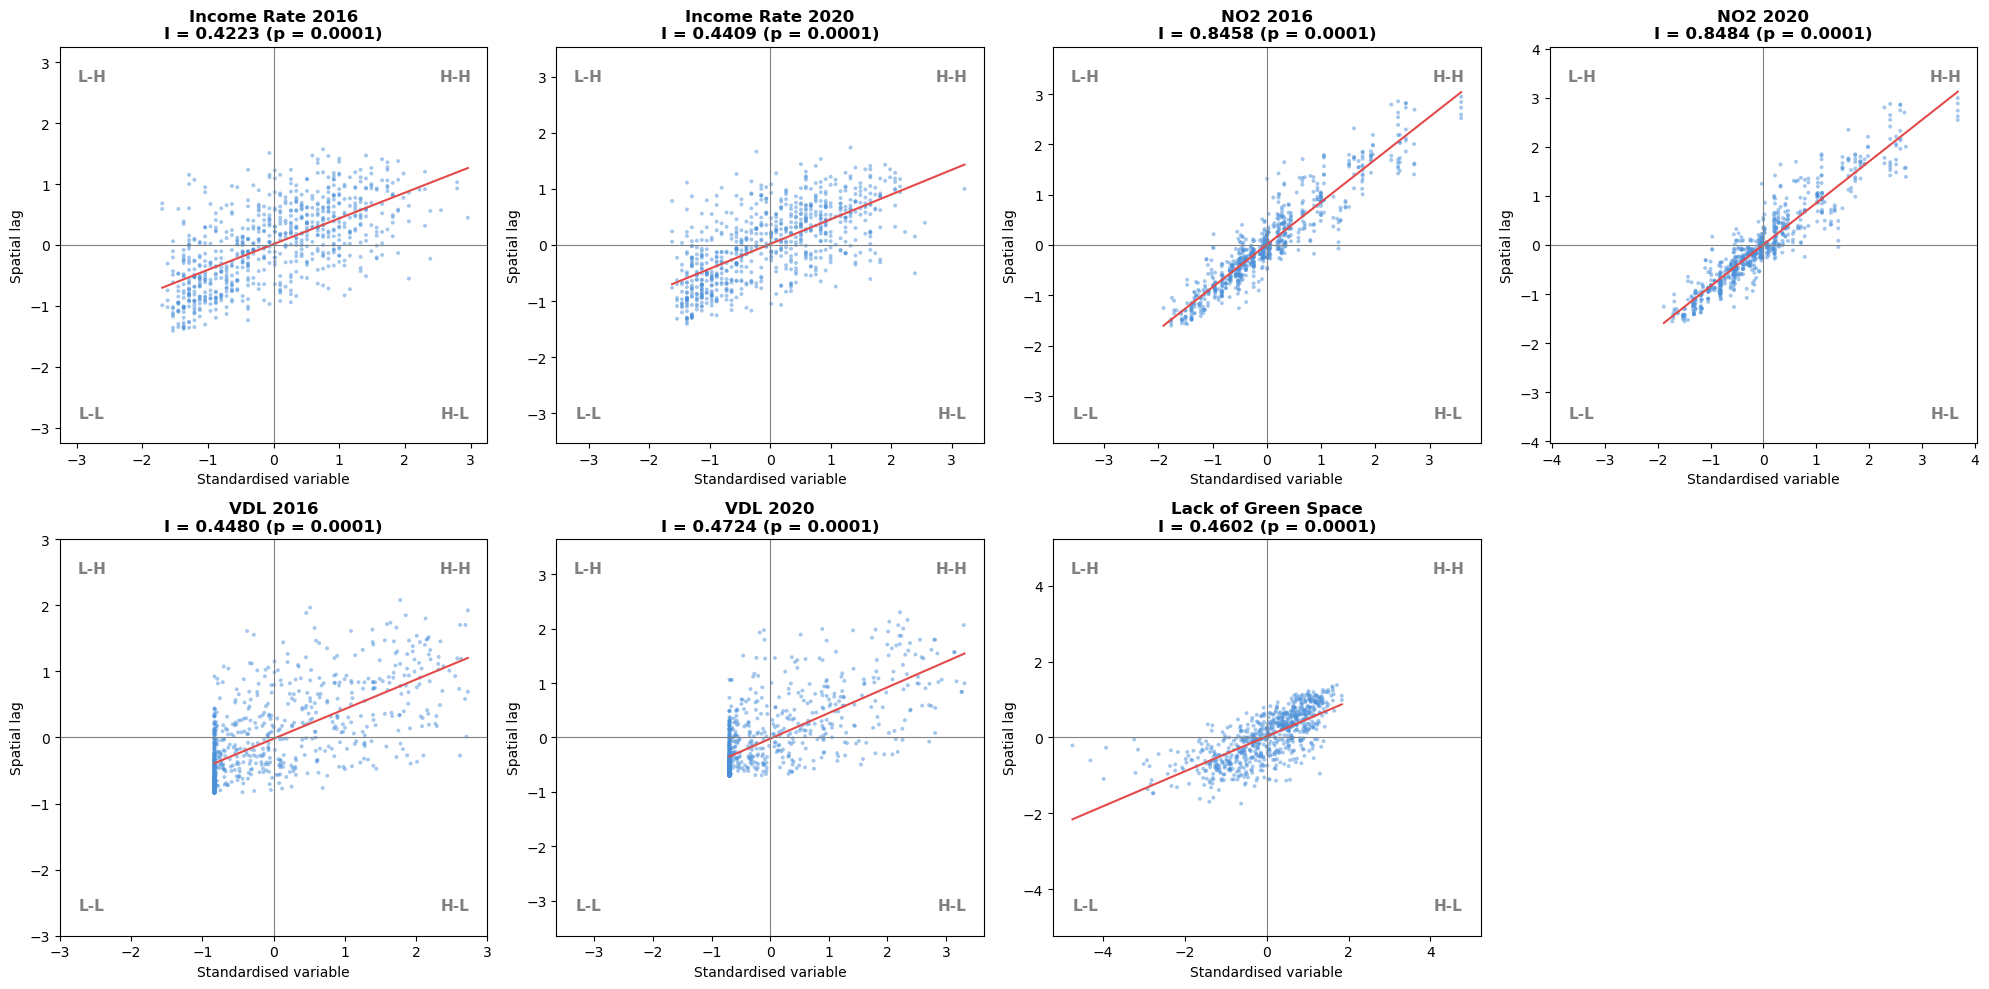

In [23]:
# Moran scatter plots for all indicators

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (name, mi) in enumerate(moran_results.items()):
    if idx >= len(axes):
        break
    ax = axes[idx]

    # Standardise
    var = variables[name].values
    z = (var - var.mean()) / var.std()
    lag = w.sparse @ z

    ax.scatter(z, lag, s=8, alpha=0.5, color='#4A90D9', edgecolors='none')

    # Regression line (slope = Moran's I)
    b, a = np.polyfit(z, lag, 1)
    x_line = np.linspace(z.min(), z.max(), 100)
    ax.plot(x_line, a + b * x_line, color='#E24B4A', linewidth=1.5)

    
    ax.axhline(0, color='grey', linewidth=0.8)
    ax.axvline(0, color='grey', linewidth=0.8)

    max_abs = max(abs(z.min()), abs(z.max()),
                  abs(lag.min()), abs(lag.max())) * 1.1
    ax.set_xlim(-max_abs, max_abs)
    ax.set_ylim(-max_abs, max_abs)

    offset = max_abs * 0.85
    ax.text( offset,  offset, 'H-H', ha='center', va='center',
            fontsize=11, color='grey', fontweight='bold')
    ax.text(-offset,  offset, 'L-H', ha='center', va='center',
            fontsize=11, color='grey', fontweight='bold')
    ax.text(-offset, -offset, 'L-L', ha='center', va='center',
            fontsize=11, color='grey', fontweight='bold')
    ax.text( offset, -offset, 'H-L', ha='center', va='center',
            fontsize=11, color='grey', fontweight='bold')

    ax.set_xlabel('Standardised variable')
    ax.set_ylabel('Spatial lag')
    ax.set_title(f'{name}\nI = {mi.I:.4f} (p = {mi.p_sim:.4f})')

for j in range(len(moran_results), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
# LISA plotting function with FDR correction
# FDR correction to reduce false positives across 746 zones

def plot_lisa(gdf, variable, w, title, ax, fdr_correct=True, alpha=0.05):
    '''Plot LISA cluster map with optional FDR correction.

    Parameters
    ----------
    fdr_correct : bool
        If True, apply Benjamini-Hochberg FDR correction.
    alpha : float
        Significance level.
    '''
    lisa = Moran_Local(variable.values, w, permutations=9999)

    if fdr_correct:
        # Benjamini-Hochberg FDR correction
        n = len(lisa.p_sim)
        sorted_idx = np.argsort(lisa.p_sim)
        sorted_p = lisa.p_sim[sorted_idx]
        bh_threshold = np.arange(1, n + 1) / n * alpha
        valid = sorted_p <= bh_threshold
        if valid.any():
            cutoff = sorted_p[np.where(valid)[0][-1]]
        else:
            cutoff = 0.0
        sig = lisa.p_sim <= cutoff
        method = f'FDR a={alpha}'
    else:
        sig = lisa.p_sim < alpha
        method = f'a={alpha}'

    # Classify: 1=HH, 2=LH, 3=LL, 4=HL, 0=not significant
    labels = lisa.q.copy()
    labels[~sig] = 0

    color_map = {0: C_NS, 1: C_HH, 2: C_LH, 3: C_LL, 4: C_HL}
    colors = [color_map[l] for l in labels]

    gdf.plot(ax=ax, color=colors, edgecolor='black', linewidth=0.2)
    ax.set_title(f'{title}\n({method}, {sig.sum()} sig.)')
    ax.axis('off')

    counts = {
        'HH': int((labels == 1).sum()),
        'LL': int((labels == 3).sum()),
        'LH': int((labels == 2).sum()),
        'HL': int((labels == 4).sum()),
        'NS': int((labels == 0).sum())
    }
    return lisa, counts

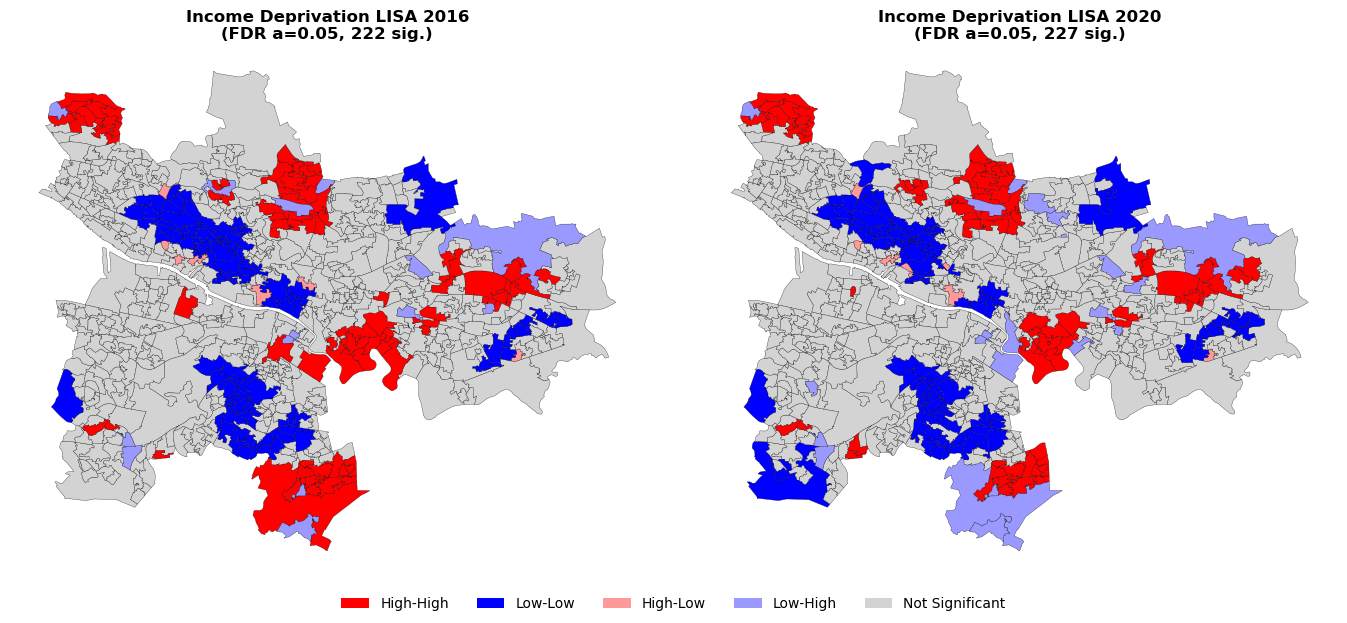

2016 clusters: {'HH': 87, 'LL': 113, 'LH': 14, 'HL': 8, 'NS': 524}
2020 clusters: {'HH': 83, 'LL': 114, 'LH': 22, 'HL': 8, 'NS': 519}


In [9]:
# Income LISA (2016 and 2020)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

lisa_inc16, counts_inc16 = plot_lisa(gdf, gdf['IncRate_2016'], w,
                                     'Income Deprivation LISA 2016', axes[0])
lisa_inc20, counts_inc20 = plot_lisa(gdf, gdf['IncRate_2020'], w,
                                     'Income Deprivation LISA 2020', axes[1])

fig.legend(handles=LISA_LEGEND, loc='lower center', ncol=5, frameon=False, fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

print(f'2016 clusters: {counts_inc16}')
print(f'2020 clusters: {counts_inc20}')

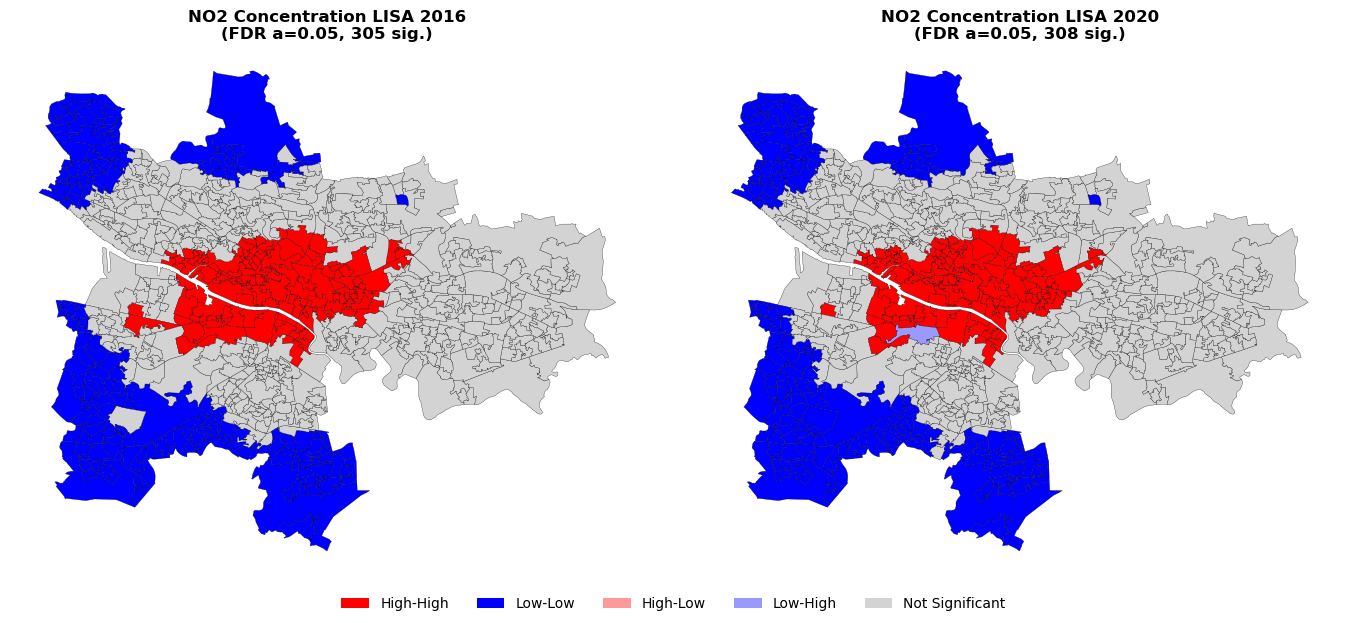

2016 clusters: {'HH': 134, 'LL': 171, 'LH': 0, 'HL': 0, 'NS': 441}
2020 clusters: {'HH': 131, 'LL': 176, 'LH': 1, 'HL': 0, 'NS': 438}


In [10]:
# NO2 LISA (2016 and 2020)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

lisa_no2_16, counts_no2_16 = plot_lisa(gdf, gdf['NO2_2016'], w,
                                        'NO2 Concentration LISA 2016', axes[0])
lisa_no2_20, counts_no2_20 = plot_lisa(gdf, gdf['NO2_2020'], w,
                                        'NO2 Concentration LISA 2020', axes[1])

fig.legend(handles=LISA_LEGEND, loc='lower center', ncol=5, frameon=False, fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

print(f'2016 clusters: {counts_no2_16}')
print(f'2020 clusters: {counts_no2_20}')

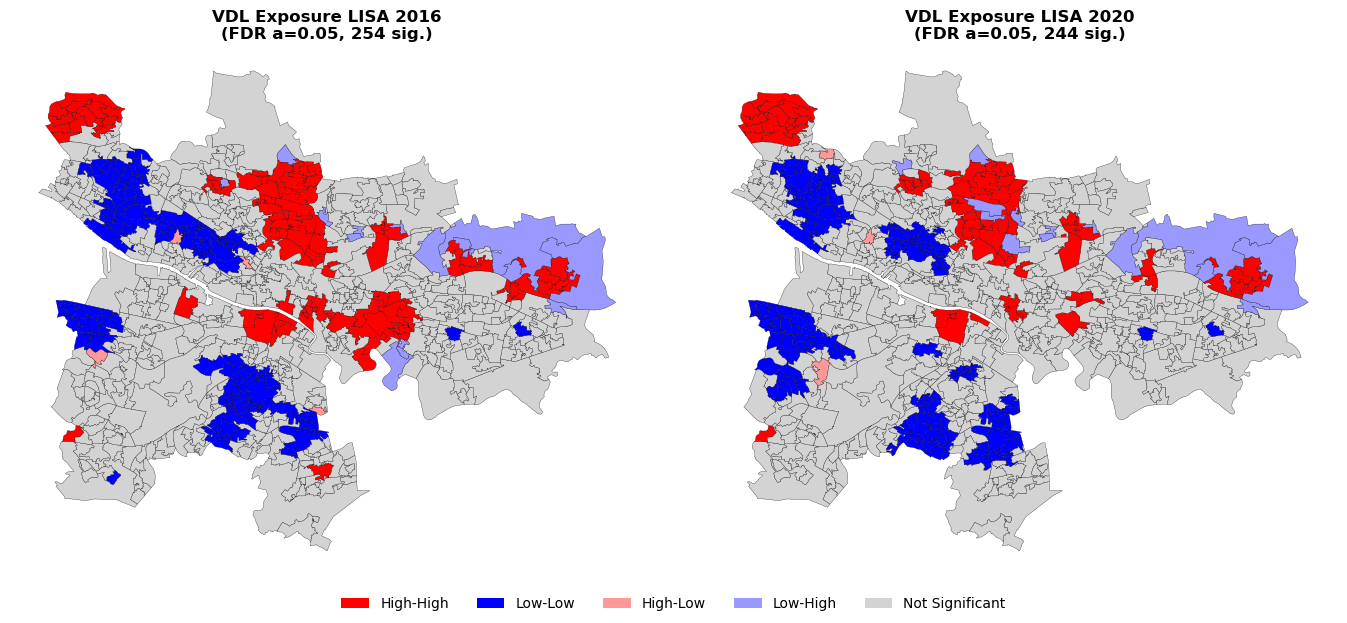

2016 clusters: {'HH': 101, 'LL': 133, 'LH': 16, 'HL': 4, 'NS': 492}
2020 clusters: {'HH': 79, 'LL': 148, 'LH': 14, 'HL': 3, 'NS': 502}


In [11]:
# VDL Exposure LISA (2016 and 2020)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

lisa_vdl16, counts_vdl16 = plot_lisa(gdf, gdf['VDL_2016'], w,
                                      'VDL Exposure LISA 2016', axes[0])
lisa_vdl20, counts_vdl20 = plot_lisa(gdf, gdf['VDL_2020'], w,
                                      'VDL Exposure LISA 2020', axes[1])

fig.legend(handles=LISA_LEGEND, loc='lower center', ncol=5, frameon=False, fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

print(f'2016 clusters: {counts_vdl16}')
print(f'2020 clusters: {counts_vdl20}')

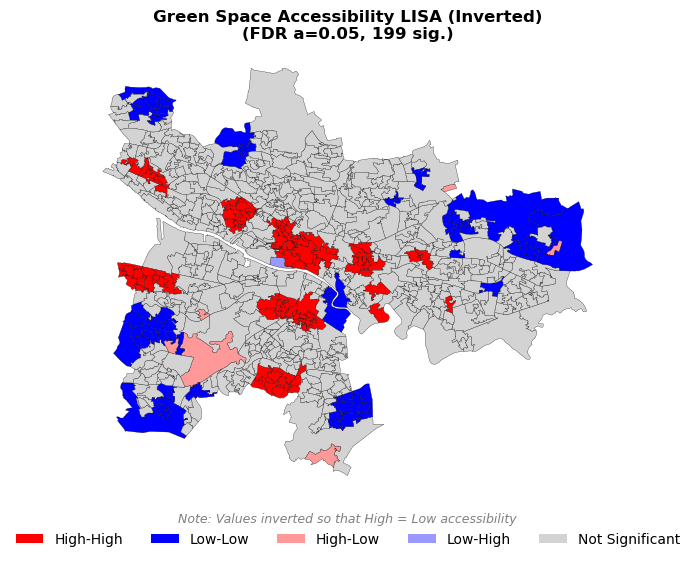

Green space clusters: {'HH': 122, 'LL': 70, 'LH': 1, 'HL': 6, 'NS': 547}


In [12]:
# Green Space accessibility LISA (single time point)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

lisa_green, counts_green = plot_lisa(gdf, gdf['NoGreen'], w,
                                     'Green Space Accessibility LISA (Inverted)', ax)

fig.legend(handles=LISA_LEGEND, loc='lower center', bbox_to_anchor=(0.5, 0.06),
           ncol=5, frameon=False, fontsize=10)
fig.text(0.5, 0.12, 'Note: Values inverted so that High = Low accessibility',
         ha='center', fontsize=9, style='italic', color='grey')

plt.tight_layout(rect=[0, 0.14, 1, 1])
plt.show()

print(f'Green space clusters: {counts_green}')

In [13]:
# Global Moran's I Summary Comparison Table

print('\n=== Temporal Change in Global Morans I ===\n')
print(f'{"Indicator":<20} {"2016":>10} {"2020":>10} {"Change":>10} {"Direction":>14}')
print('-' * 64)

pairs = [
    ('Income Rate', 'Income Rate 2016', 'Income Rate 2020'),
    ('NO2',         'NO2 2016',          'NO2 2020'),
    ('VDL',         'VDL 2016',          'VDL 2020')
]

for label, k16, k20 in pairs:
    i16 = moran_results[k16].I
    i20 = moran_results[k20].I
    change = i20 - i16
    direction = 'More clustered' if change > 0 else 'Less clustered'
    print(f'{label:<20} {i16:>10.4f} {i20:>10.4f} {change:>+10.4f} {direction:>14}')

print(f'\n{"Green Space":<20} {moran_results["Lack of Green Space"].I:>10.4f} {"(static)":>10}')


=== Temporal Change in Global Morans I ===

Indicator                  2016       2020     Change      Direction
----------------------------------------------------------------
Income Rate              0.4223     0.4409    +0.0186 More clustered
NO2                      0.8458     0.8484    +0.0026 More clustered
VDL                      0.4480     0.4724    +0.0245 More clustered

Green Space              0.4602   (static)


In [ ]:
# Getis-Ord Gi* (Hotspot Analysis)

def plot_hotspot(gdf, variable, w, title, ax):
    '''Plot Getis-Ord Gi* hot/cold spot map with confidence levels.'''
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        g = G_Local(variable.values, w, transform='r', permutations=9999, star=True)

    # Classify by z-score direction and p-value thresholds
    spots = np.zeros(len(gdf))

    # Hot spots (positive z-score)
    spots[(g.Zs > 0) & (g.p_sim < 0.10) & (g.p_sim >= 0.05)] = 1   # 90%
    spots[(g.Zs > 0) & (g.p_sim < 0.05) & (g.p_sim >= 0.01)] = 2   # 95%
    spots[(g.Zs > 0) & (g.p_sim < 0.01)] = 3                        # 99%

    # Cold spots (negative z-score)
    spots[(g.Zs < 0) & (g.p_sim < 0.10) & (g.p_sim >= 0.05)] = -1  # 90%
    spots[(g.Zs < 0) & (g.p_sim < 0.05) & (g.p_sim >= 0.01)] = -2  # 95%
    spots[(g.Zs < 0) & (g.p_sim < 0.01)] = -3                       # 99%

    color_map = {
        -3: '#2166AC', -2: '#67A9CF', -1: '#D1E5F0',
         0: '#D3D3D3',
         1: '#FDDBC7',  2: '#EF8A62',  3: '#B2182B'
    }
    colors = [color_map[s] for s in spots]

    gdf.plot(ax=ax, color=colors, edgecolor='black', linewidth=0.2)
    ax.set_title(title)
    ax.axis('off')

    counts = {
        'Hot 99%':  int((spots == 3).sum()),
        'Hot 95%':  int((spots == 2).sum()),
        'Hot 90%':  int((spots == 1).sum()),
        'Not sig':  int((spots == 0).sum()),
        'Cold 90%': int((spots == -1).sum()),
        'Cold 95%': int((spots == -2).sum()),
        'Cold 99%': int((spots == -3).sum())
    }
    return g, counts

c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values 

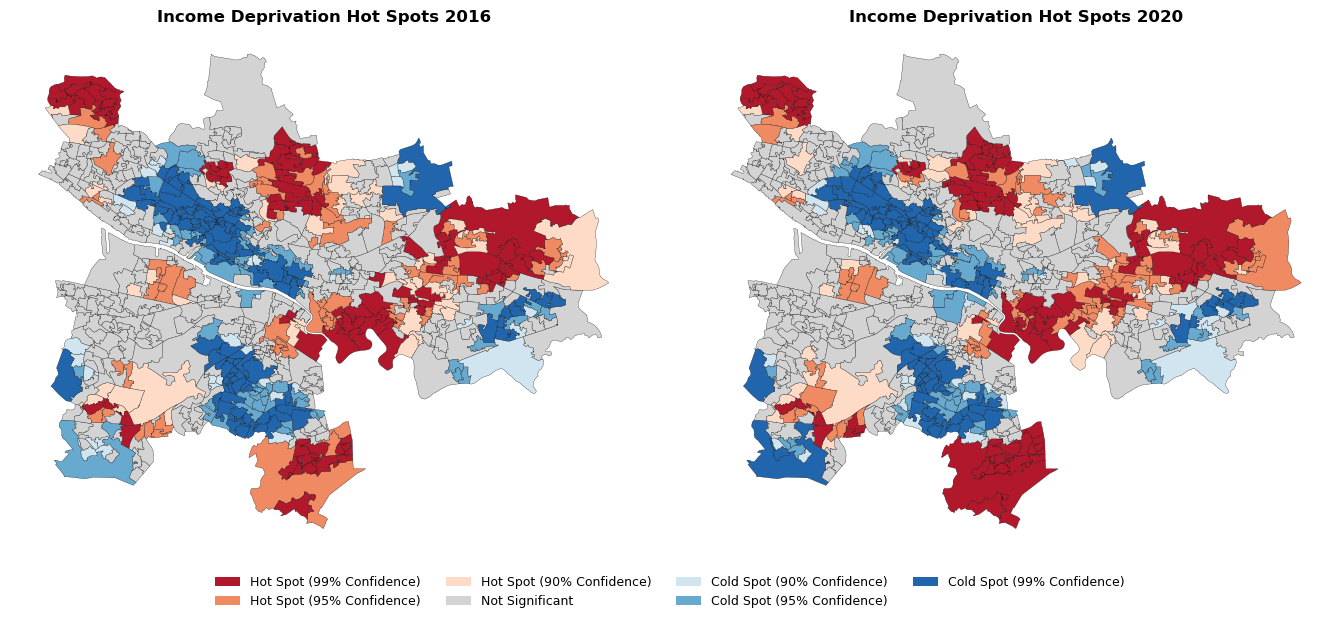

2016: {'Hot 99%': 90, 'Hot 95%': 69, 'Hot 90%': 50, 'Not sig': 329, 'Cold 90%': 36, 'Cold 95%': 64, 'Cold 99%': 108}
2020: {'Hot 99%': 93, 'Hot 95%': 78, 'Hot 90%': 46, 'Not sig': 318, 'Cold 90%': 36, 'Cold 95%': 67, 'Cold 99%': 108}


In [15]:
# Income Deprivation Hotspot Analysis (2016 and 2020)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

g_inc16, counts_g16 = plot_hotspot(gdf, gdf['IncRate_2016'], w,
                                    'Income Deprivation Hot Spots 2016', axes[0])
g_inc20, counts_g20 = plot_hotspot(gdf, gdf['IncRate_2020'], w,
                                    'Income Deprivation Hot Spots 2020', axes[1])

fig.legend(handles=HOTSPOT_LEGEND, loc='lower center', ncol=4, frameon=False, fontsize=9)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

print(f'2016: {counts_g16}')
print(f'2020: {counts_g20}')

c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values 

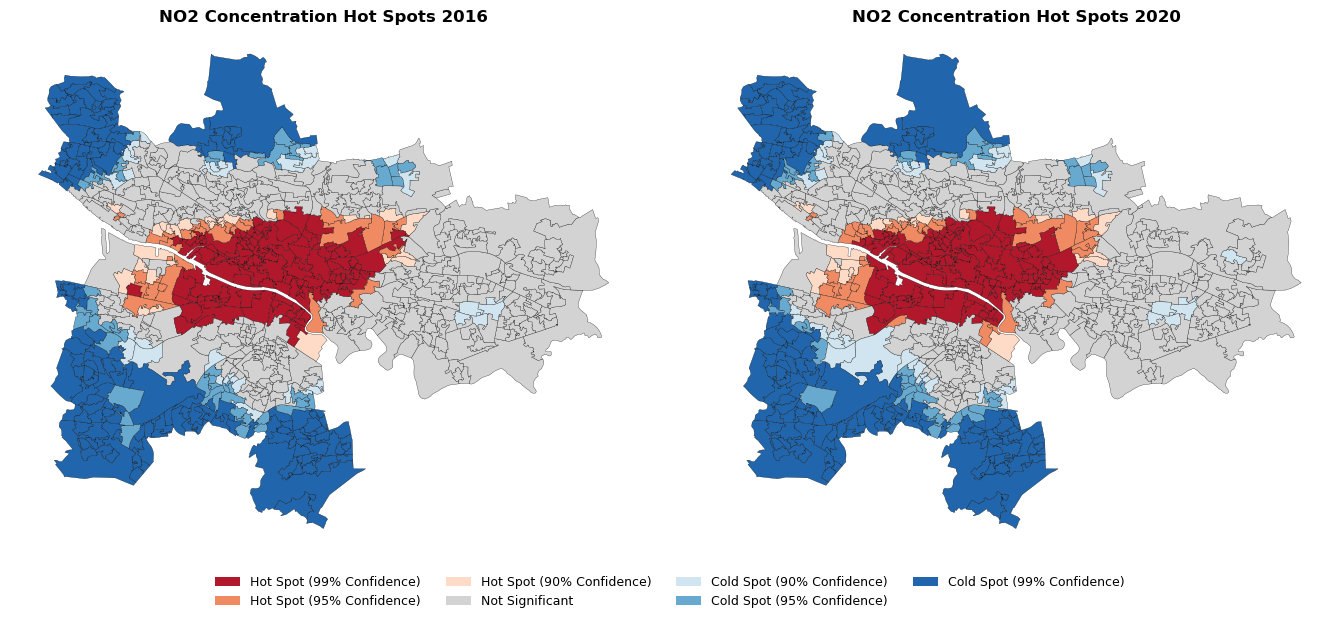

2016: {'Hot 99%': 122, 'Hot 95%': 32, 'Hot 90%': 27, 'Not sig': 329, 'Cold 90%': 34, 'Cold 95%': 50, 'Cold 99%': 152}
2020: {'Hot 99%': 121, 'Hot 95%': 39, 'Hot 90%': 22, 'Not sig': 320, 'Cold 90%': 41, 'Cold 95%': 46, 'Cold 99%': 157}


In [16]:
# NO2 Concentration Hotspot Analysis (2016 and 2020)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

g_no2_16, counts_no2_g16 = plot_hotspot(gdf, gdf['NO2_2016'], w,
                                         'NO2 Concentration Hot Spots 2016', axes[0])
g_no2_20, counts_no2_g20 = plot_hotspot(gdf, gdf['NO2_2020'], w,
                                         'NO2 Concentration Hot Spots 2020', axes[1])

fig.legend(handles=HOTSPOT_LEGEND, loc='lower center', ncol=4, frameon=False, fontsize=9)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

print(f'2016: {counts_no2_g16}')
print(f'2020: {counts_no2_g20}')

c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values 

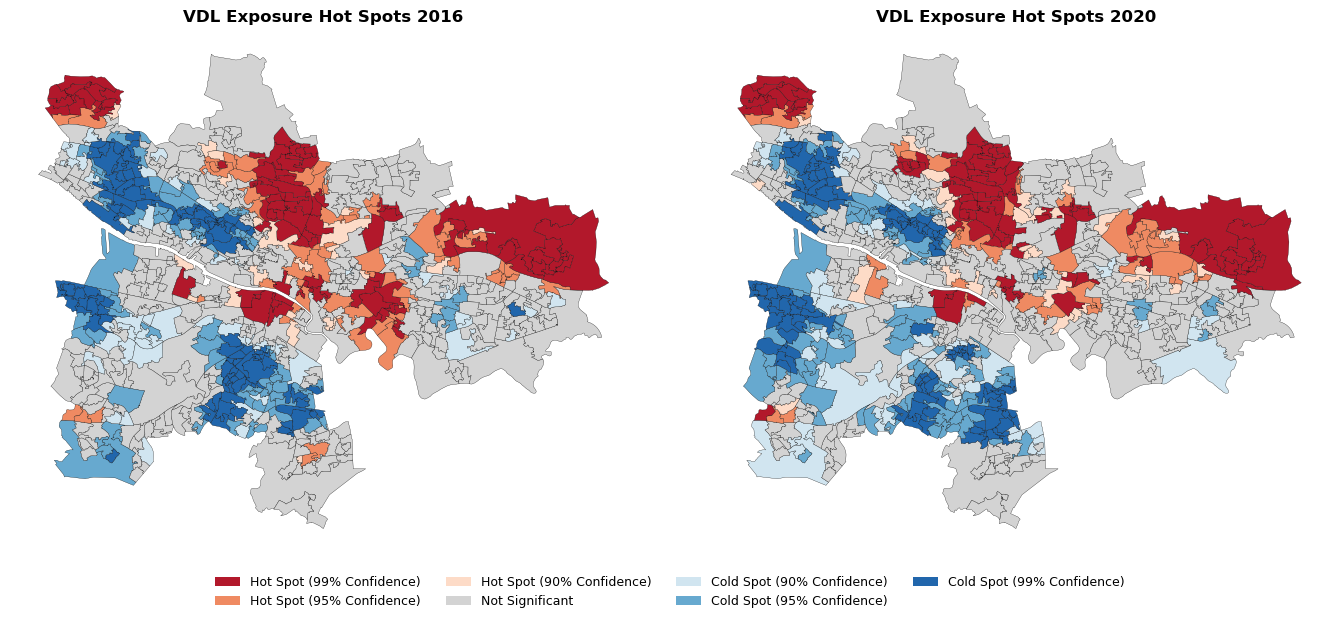

2016: {'Hot 99%': 87, 'Hot 95%': 60, 'Hot 90%': 24, 'Not sig': 325, 'Cold 90%': 55, 'Cold 95%': 88, 'Cold 99%': 107}
2020: {'Hot 99%': 86, 'Hot 95%': 40, 'Hot 90%': 32, 'Not sig': 306, 'Cold 90%': 62, 'Cold 95%': 105, 'Cold 99%': 115}


In [17]:
# VDL exposure Hotspot Analysis (2016 and 2020)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

g_vdl16, counts_vdl_g16 = plot_hotspot(gdf, gdf['VDL_2016'], w,
                                        'VDL Exposure Hot Spots 2016', axes[0])
g_vdl20, counts_vdl_g20 = plot_hotspot(gdf, gdf['VDL_2020'], w,
                                        'VDL Exposure Hot Spots 2020', axes[1])

fig.legend(handles=HOTSPOT_LEGEND, loc='lower center', ncol=4, frameon=False, fontsize=9)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

print(f'2016: {counts_vdl_g16}')
print(f'2020: {counts_vdl_g20}')

c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)


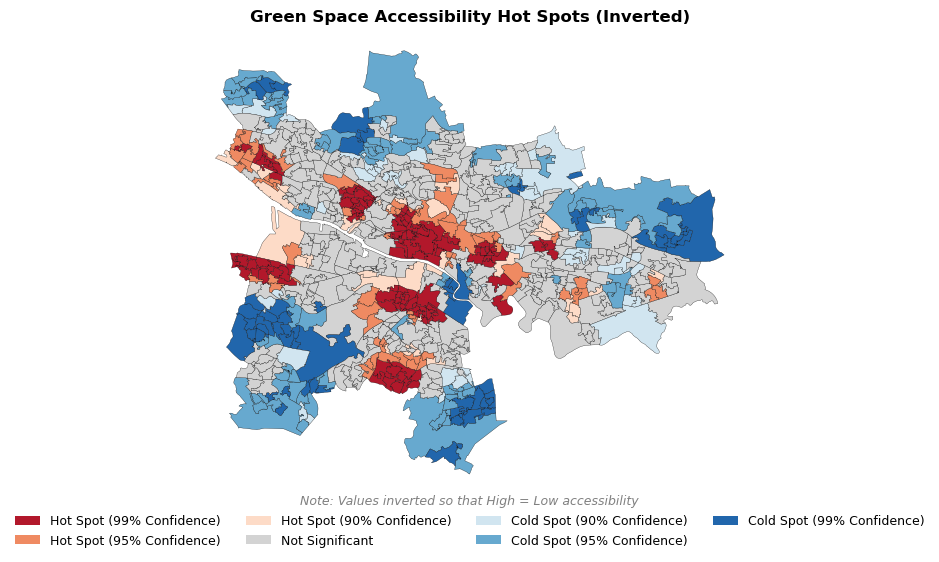

Green space: {'Hot 99%': 113, 'Hot 95%': 70, 'Hot 90%': 35, 'Not sig': 335, 'Cold 90%': 47, 'Cold 95%': 85, 'Cold 99%': 61}


In [22]:
# Green Space Accessibility Hotspot Analysis (single time point)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

g_green, counts_green_g = plot_hotspot(gdf, gdf['NoGreen'], w,
                                        'Green Space Accessibility Hot Spots (Inverted)', ax)

fig.legend(handles=HOTSPOT_LEGEND, loc='lower center', bbox_to_anchor=(0.5, 0.06),
           ncol=4, frameon=False, fontsize=9)
fig.text(0.5, 0.15, 'Note: Values inverted so that High = Low accessibility',
         ha='center', fontsize=9, style='italic', color='grey')

plt.tight_layout(rect=[0, 0.14, 1, 1])
plt.show()

print(f'Green space: {counts_green_g}')

In [2]:
import subprocess
subprocess.run(['jupyter', 'nbconvert', '--to', 'html', 'ESDA_Analysis.ipynb'])

CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', 'ESDA_Analysis.ipynb'], returncode=0)